## Datasets Exploration 

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from preprocessing_class import Preprocessing, load_movies, load_pres

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import string
import codecs
import re
import wordcloud

### Movies dataset

In [2]:
# load dataset

# 0 = neg, 1 = pos
path = "./Dataset/movies1000/"
alltxts,alllabs = load_movies(path)
allabs_name = np.where(np.array(alllabs) == 0, 'neg', 'pos')

In [3]:
len(alltxts), np.unique(alllabs, return_counts=True)

(2000, (array([0, 1]), array([1000, 1000])))

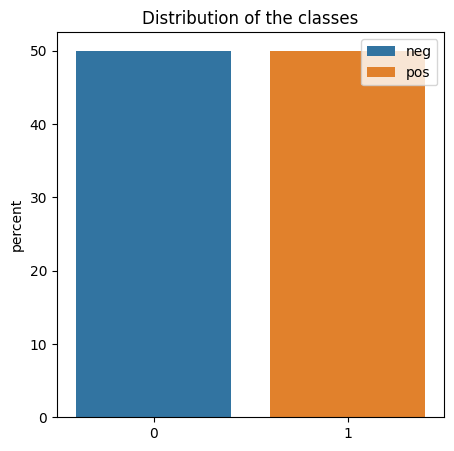

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
sns.countplot(x=alllabs, ax=ax, hue=allabs_name, stat="percent")
plt.title("Distribution of the classes")
plt.savefig("images/movie/movie_class_dist.pdf", bbox_inches='tight')

#### Exploration du vocabulaire

In [12]:
# bag of words, with simple préprocessing (lowercase, no punctuation, no URLS)
from nltk.corpus import stopwords 
final_stopwords_list = stopwords.words('english') # stopwords.words('english') 

prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = True, 
        lang = "english",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )

all_texts_prec = [prep.process(text) for text in alltxts]

In [13]:
alltxts[0], all_texts_prec[0]

('bad . bad . \nbad . \nthat one word seems to pretty much sums up beyond the valley of the dolls . \nif that summary isn\'t enough for you , how about t&a , t&a , t&a ? \nstill haven\'t got the point ? \nother than director russ meyer\'s predilection for casting attractive large breasted women who ultimately expose the afore-mentioned anatomical areas , there is really only one other reason to recommend even taking a look at this movie . \nthat is the fact that it was co-written by famed film critic roger ebert , who also was responsible for the screenplay . \nafter watching this movie you will never be able to sit through another one of his reviews where he gives a movie a thumbs down for bad writing with a straight face . \nthis movie stinks out loud . \nquite frankly , this movie deserves a . \nbut there are parts of it that are so bad they are almost funny . \nso i\'m giving it a . \nand maybe that is too generous . \nright from the opening credits , i knew that i had a class-a bo

In [21]:
cv = CountVectorizer(stop_words="english")
X = cv.fit_transform(all_texts_prec)
vocab = cv.get_feature_names_out()
frequencies = np.array(X.sum(axis=0)).flatten()

idx = np.argsort(frequencies)[::-1]
print(len(vocab))

39058


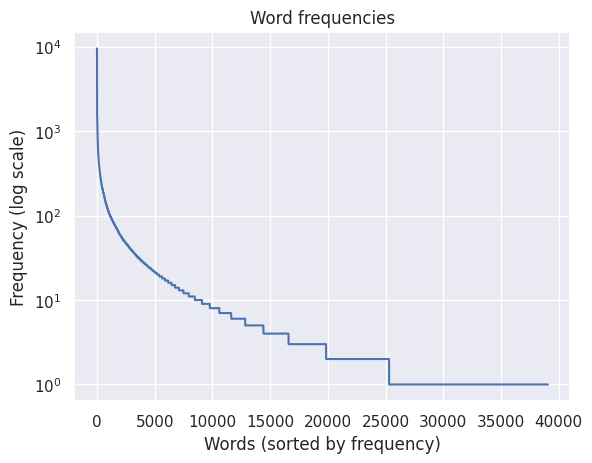

In [22]:
sns.lineplot(x=np.arange(len(vocab)), y=frequencies[idx])
sns.set_theme(style="darkgrid")
plt.grid(True)
plt.title("Word frequencies")
plt.xlabel("Words (sorted by frequency)")
plt.ylabel("Frequency (log scale)")
plt.yscale('log')

plt.savefig("images/movie/movies_word_freq.pdf", bbox_inches='tight')

Text(0, 0.5, 'Frequency (log scale)')

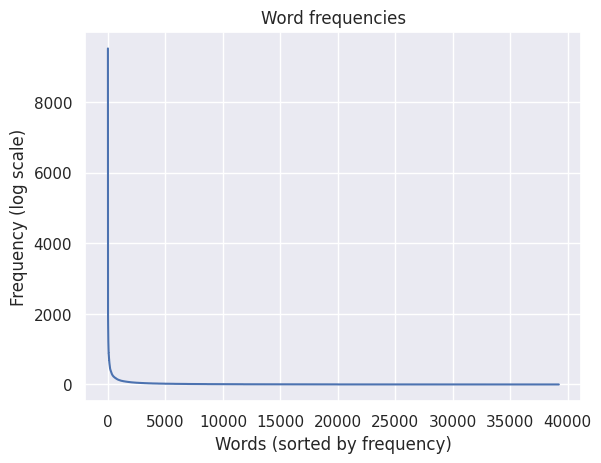

In [20]:
sns.lineplot(x=np.arange(len(vocab)), y=frequencies[idx])
sns.set_theme(style="darkgrid")
plt.grid(True)
plt.title("Word frequencies")
plt.xlabel("Words (sorted by frequency)")
plt.ylabel("Frequency (log scale)")

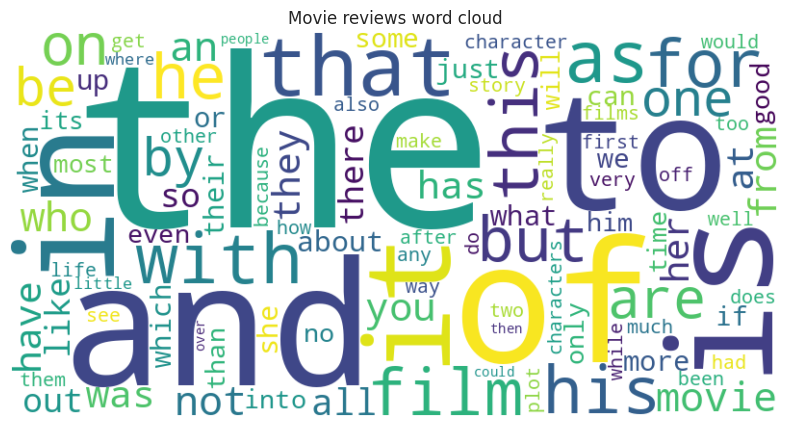

In [ ]:
# top 100 words most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab[idx], frequencies[idx]))) #.to_file("images/movies_wordcloud.pdf")

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movie reviews word cloud")

plt.savefig("images/movies_wordcloud.pdf", bbox_inches='tight')

We remove the stop words to see the most frequent words

In [220]:
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(all_texts_prec)
vocab = cv.get_feature_names_out()
frequencies = np.array(X.sum(axis=0)).flatten()

idx = np.argsort(frequencies)[::-1]
print(len(vocab))

39058


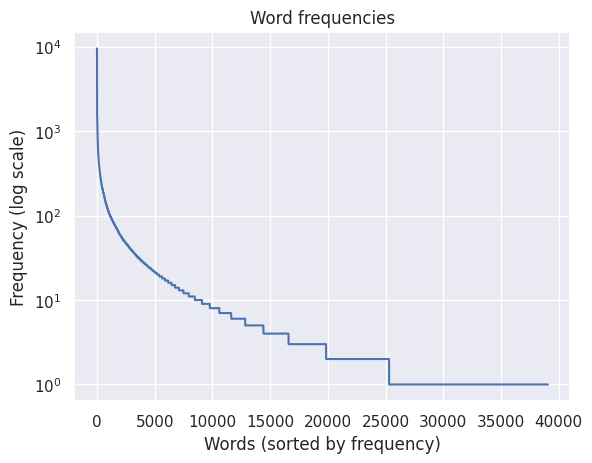

In [172]:
sns.lineplot(x=np.arange(len(vocab)), y=frequencies[idx])
sns.set_theme(style="darkgrid")
plt.grid(True)
plt.title("Word frequencies")
plt.xlabel("Words (sorted by frequency)")
plt.ylabel("Frequency (log scale)")
plt.yscale('log')

# plt.savefig("images/movies_word_freq.pdf", bbox_inches='tight')

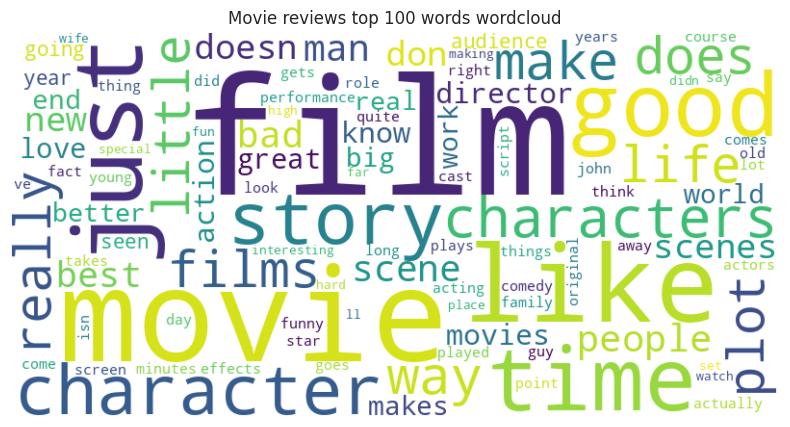

In [221]:
# top 100 words most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab[idx], frequencies[idx]))) #.to_file("images/movies_wordcloud.pdf")

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movie reviews top 100 words wordcloud")

plt.savefig("images/speaker_wordcloud_no_stopw.pdf", bbox_inches='tight')

100 mots avec la plus grande frequence doc:
['film' 'movie' 'like' 'just' 'time' 'good' 'story' 'character' 'make'
 'way' 'characters' 'does' 'little' 'director' 'plot' 'really' 'people'
 'best' 'films' 'doesn' 'life' 'don' 'man' 'scene' 'scenes' 'bad' 'new'
 'know' 'end' 'movies' 'makes' 'work' 'great' 'better' 'love' 'big' 'gets'
 'long' 'audience' 'seen' 'going' 'real' 'isn' 'year' 'role' 'look'
 'years' 'world' 'old' 'come' 'things' 'performance' 'right' 'thing'
 'think' 'plays' 'say' 'fact' 'comes' 'actually' 'action' 've' 'screen'
 'cast' 'played' 'script' 'takes' 'acting' 'did' 'goes' 'actors' 'away'
 'young' 'funny' 'comedy' 'lot' 'point' 'course' 'set' 'far' 'making'
 'interesting' 'minutes' 'day' 'quite' 'place' 'john' 'watch' 'star'
 'times' 'instead' 'want' 'hard' 'trying' 'having' 'help' 'didn' 'fun'
 'high' 'll']


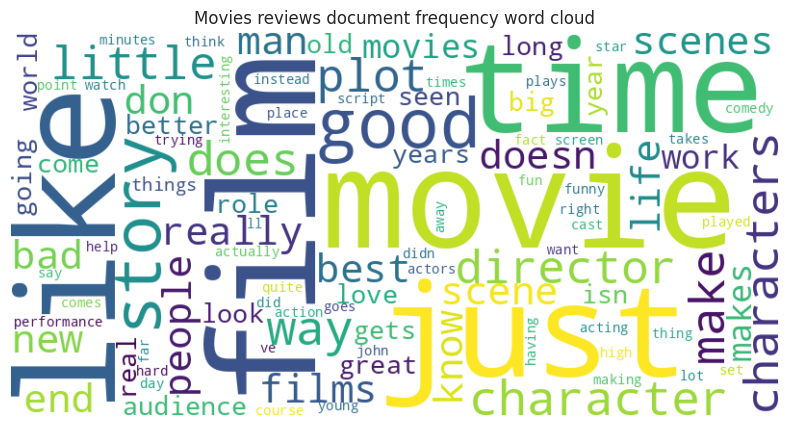

In [170]:
# 100 mots frequences documentaires
vect_tfidf = TfidfVectorizer(use_idf= True, smooth_idf=True, sublinear_tf=False, stop_words='english')
X = vect_tfidf.fit_transform(all_texts_prec)
vocab = vect_tfidf.get_feature_names_out()
idf = vect_tfidf.idf_

# doc freq = inverse of idf, so getting the biggest df means getting the smallest idf 
idx_top_df = np.argsort(idf)[:100]
words_top_df = vocab[idx_top_df] 

wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab[idx_top_df], 1/idf[idx_top_df]))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movies reviews document frequency word cloud")

# plt.savefig("images/movies_df_wordcloud_no_stopw.pdf", bbox_inches='tight')

print(f"100 mots avec la plus grande frequence doc:")
print(words_top_df)

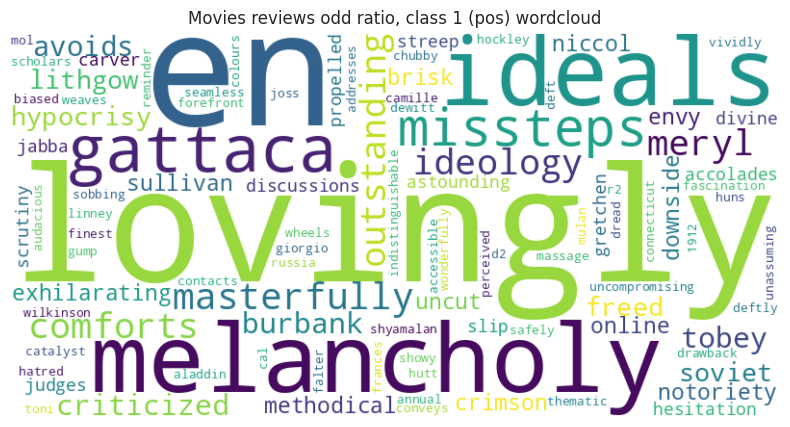

In [206]:
# 100 mots odd ratio
vect = CountVectorizer(stop_words='english', binary=True)
X = vect.fit_transform(all_texts_prec)
vocab = vect.get_feature_names_out()

idx0 =  np.where(np.array(alllabs) == 0)[0]
idx1 =  np.where(np.array(alllabs) == 1)[0]

X_class1 = X[idx1]
X_class0 = X[idx0]

a = np.array(X_class1.sum(axis=0)).flatten()
c = np.array(X_class0.sum(axis=0)).flatten()

b = X_class1.shape[0] - a
d = X_class0.shape[0] - c

odd_r = ((a + 1) / (b + 1)) / ((c + 1) / (d + 1))
log_or = np.log(odd_r)

# class 1 pos
idx_top = np.argsort(log_or)[-100:]
top_words = vocab[idx_top]

wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(top_words, np.abs(log_or[idx_top])))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movies reviews odd ratio, class 1 (pos) wordcloud")

plt.savefig("images/movies_OR_wordcloud_no_stopw_pos.pdf", bbox_inches='tight')

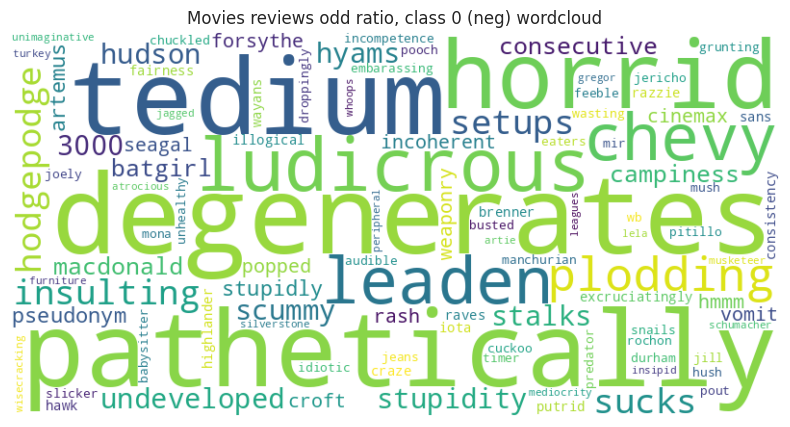

In [208]:
# class 0 neg
idx_bottom = np.argsort(log_or)[:100]
less_words = vocab[idx_bottom]

wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(less_words, -log_or[idx_bottom])))

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movies reviews odd ratio, class 0 (neg) wordcloud")

plt.savefig("images/movies_OR_wordcloud_no_stopw_neg.pdf", bbox_inches='tight')

In [24]:
# zipf law with stopwords !
vect = CountVectorizer(stop_words=None, binary=True)
X = vect.fit_transform(all_texts_prec)

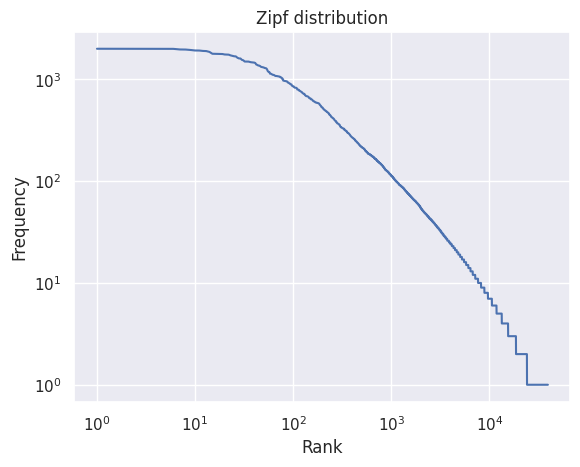

In [ ]:
# zipf law
total_counts = np.asarray(X.sum(axis=0)).ravel()
sorted_counts = np.sort(total_counts)[::-1] # descending order
ranks = np.arange(1,len(sorted_counts)+1)
plt.plot(ranks,sorted_counts)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf distribution")
plt.xscale('log')
plt.yscale('log')
plt.savefig("images/movie/movies_zipf.pdf", bbox_inches='tight')

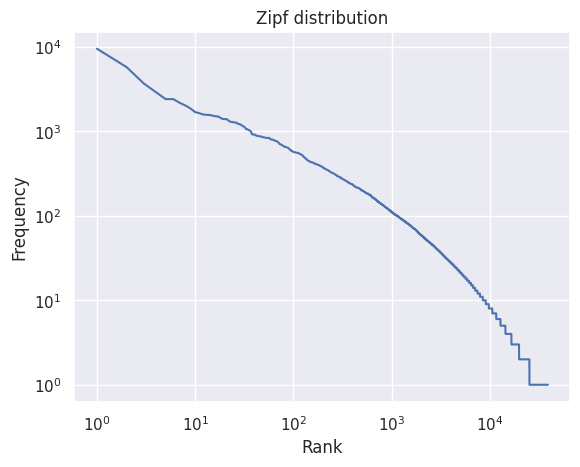

In [23]:
# zipf law
total_counts = np.asarray(X.sum(axis=0)).ravel()
sorted_counts = np.sort(total_counts)[::-1] # descending order
ranks = np.arange(1,len(sorted_counts)+1)
plt.plot(ranks,sorted_counts)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf distribution")
plt.xscale('log')
plt.yscale('log')
# plt.savefig("images/movies_zipf_no_stopw.pdf", bbox_inches='tight')


100 bigrammes les plus freq:
['action film' 'action movie' 'action scenes' 'action sequences' 'bad guy'
 'bad guys' 'bad movie' 'batman robin' 'best friend' 'big screen'
 'blair witch' 'boogie nights' 'box office' 'bruce willis'
 'character development' 'comic book' 'comic relief' 'computer generated'
 'did summer' 'don know' 'don think' 'eddie murphy' 'end film'
 'entire film' 'falls love' 'feels like' 'film does' 'film doesn'
 'film film' 'film just' 'film like' 'film opens' 'film really'
 'film takes' 'films like' 'fun watch' 'good film' 'good job' 'good movie'
 'good time' 'great deal' 'half hour' 'haven seen' 'high school'
 'hong kong' 'horror film' 'horror films' 'jackie brown' 'jackie chan'
 'jim carrey' 'john travolta' 'just like' 'just plain' 'know did'
 'las vegas' 'little bit' 'long time' 'look like' 'looks like'
 'love story' 'main character' 'main characters' 'make film' 'make sense'
 'martial arts' 'motion picture' 'movie just' 'movie like' 'movies like'
 'new york' 'pha

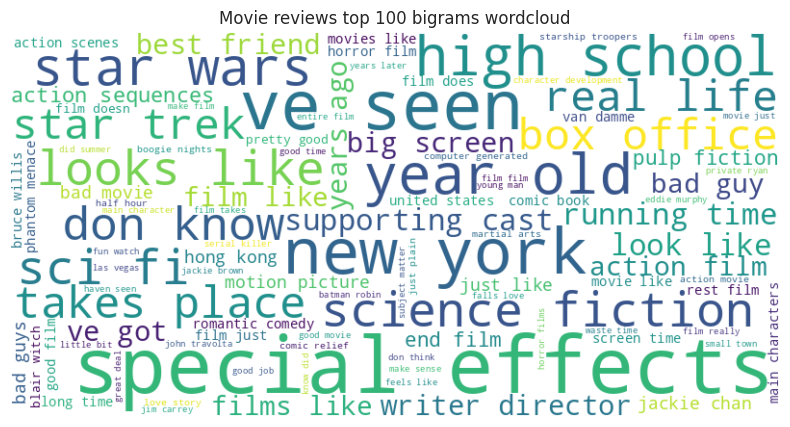

In [178]:
# bigrams most present
vectorizer_bi = CountVectorizer(ngram_range=(2, 2), max_features=100, stop_words='english')
X_bi = vectorizer_bi.fit_transform(all_texts_prec)

vocab_bi = np.array(vectorizer_bi.get_feature_names_out())
frequencies = np.array(X_bi.sum(axis=0)).flatten()

# top 100 bigram most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab_bi, frequencies))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movie reviews top 100 bigrams wordcloud")

plt.savefig("images/movies_bigrams_wordcloud_no_stopw.pdf", bbox_inches='tight')

print("\n100 bigrammes les plus freq:")
print(vocab_bi[:100])


100 trigrams les plus freq:
['10 scale scale' '10 things hate' '1999 eugene novikov'
 '2001 space odyssey' 'amazing potent stuff' 'andrew kevin walker'
 'babe pig city' 'based true story' 'best films year'
 'best friend wedding' 'better staying home' 'billy bob thornton'
 'blair witch project' 'bring friend amazing' 'casper van dien'
 'catherine zeta jones' 'claude van damme' 'consider portions following'
 'creaky better staying' 'cuba gooding jr' 'does good job'
 'does great job' 'doesn make sense' 'driving miss daisy' 'dusk till dawn'
 'episode phantom menace' 'facts film stars' 'film takes place'
 'film ve seen' 'flying inkpot rating' 'following text spoilers'
 'freddie prinze jr' 'friend amazing potent' 'good bring friend'
 'gotcha pretty good' 'granger movie gauge' 'gus van sant'
 'home gotcha pretty' 'hong kong action' 'house haunted hill'
 'inkpot rating wait' 'international film festival' 'jamie lee curtis'
 'jar jar binks' 'jay silent bob' 'jean claude van' 'jennifer love hew

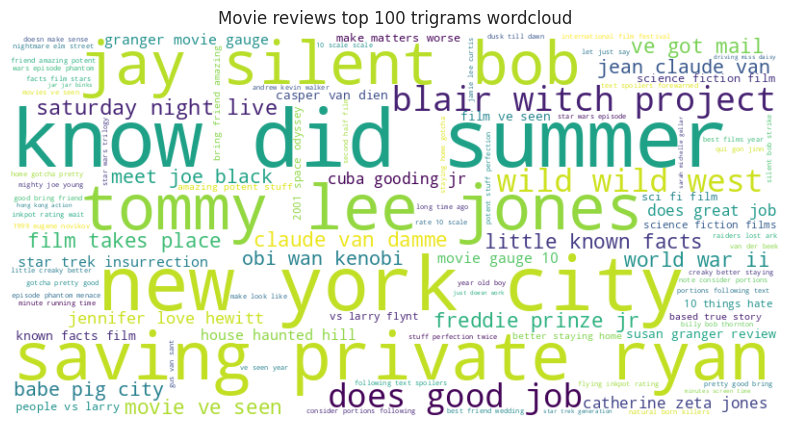

In [177]:
# tri-grams
vectorizer_tri = CountVectorizer(ngram_range=(3, 3), max_features=100, stop_words='english')
X_tri = vectorizer_tri.fit_transform(all_texts_prec)

vocab_tri = np.array(vectorizer_tri.get_feature_names_out())
frequencies = np.array(X_tri.sum(axis=0)).flatten()

# top 100 bigram most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab_tri, frequencies))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Movie reviews top 100 trigrams wordcloud")

plt.savefig("images/movies_trigrams_wordcloud_no_stopw.pdf", bbox_inches='tight')

print("\n100 trigrams les plus freq:")
print(vocab_tri[:100])

---

### Speaker dataset

In [27]:
# loading the dataset

def load_pres(fname):
    alltxts = []
    alllabs = []
    s=codecs.open(fname, 'r','utf-8') # pour régler le codage
    while True:
        txt = s.readline()
        if(len(txt))<5:
            break
        #
        lab = re.sub(r"<[0-9]*:[0-9]*:(.)>.*","\\1",txt)
        txt = re.sub(r"<[0-9]*:[0-9]*:.>(.*)","\\1",txt)
        if lab.count('M') >0:
            alllabs.append(-1)
        else:
            alllabs.append(1)
        alltxts.append(txt)

      # M = -1, C = 1
    return alltxts,alllabs

fname = "./Dataset/corpus.tache1.learn.utf8"
alltxts, alllabs = load_pres(fname)
allabs_name = np.where(np.array(alllabs) == -1, 'M', 'C')
text = [t.split() for t in alltxts] # p is the class

In [28]:
len(alltxts), np.unique(alllabs, return_counts=True)

(57413, (array([-1,  1]), array([ 7523, 49890])))

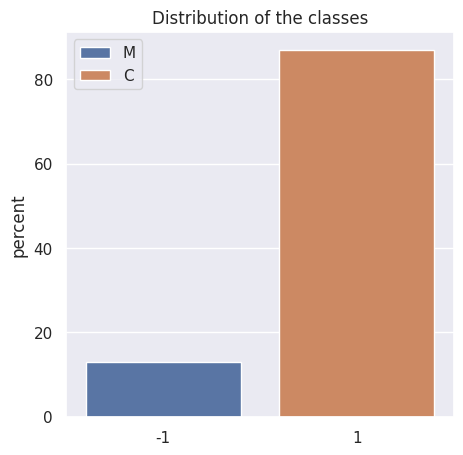

In [228]:
fig, ax = plt.subplots(figsize=(5,5))
sns.countplot(x=alllabs, ax=ax, hue=allabs_name, stat="percent")
plt.title("Distribution of the classes")
plt.savefig("images/movies_class_dist.pdf", bbox_inches='tight')

In [29]:
# bag of words, with simple préprocessing (lowercase, no punctuation, no URLS)
from nltk.corpus import stopwords 
final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = False, 
        lang = "french",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )

all_texts_prec = [prep.process(text) for text in alltxts]

27294


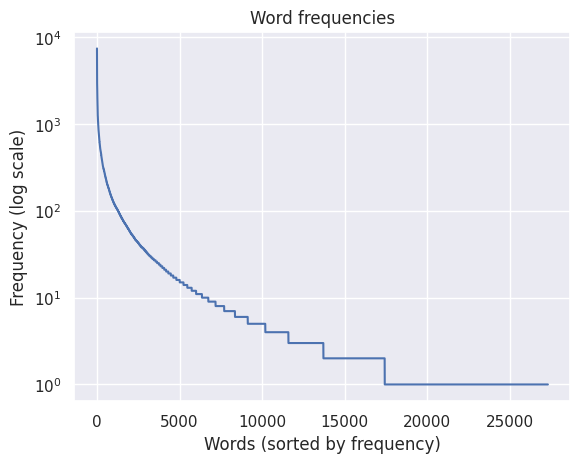

In [ ]:
cv = CountVectorizer(stop_words=final_stopwords_list)
X = cv.fit_transform(all_texts_prec)
vocab = cv.get_feature_names_out()
frequencies = np.array(X.sum(axis=0)).flatten()

idx = np.argsort(frequencies)[::-1]
print(len(vocab))

sns.lineplot(x=np.arange(len(vocab)), y=frequencies[idx])
sns.set_theme(style="darkgrid")
plt.grid(True)
plt.title("Word frequencies")
plt.xlabel("Words (sorted by frequency)")
plt.ylabel("Frequency (log scale)")
plt.yscale('log')

plt.savefig("images/speaker_word_freq.pdf", bbox_inches='tight')

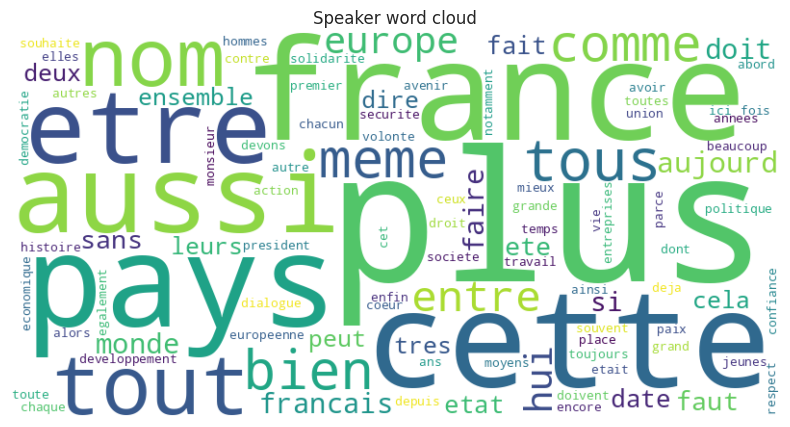

In [ ]:
# top 100 words most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab[idx], frequencies[idx]))) #.to_file("images/movies_wordcloud.pdf")

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Speaker word cloud")

plt.savefig("images/speaker_wordcloud.pdf", bbox_inches='tight')

100 mots avec la plus grande frequence doc:
['plus' 'france' 'cette' 'aussi' 'pays' 'etre' 'tout' 'tous' 'bien' 'nom'
 'meme' 'comme' 'hui' 'aujourd' 'entre' 'doit' 'europe' 'monde' 'faire'
 'francais' 'faut' 'si' 'ete' 'sans' 'fait' 'etat' 'date' 'cela' 'dire'
 'ensemble' 'peut' 'deux' 'developpement' 'dont' 'tres' 'leurs' 'encore'
 'politique' 'autres' 'president' 'monsieur' 'toutes' 'vie' 'ici' 'ceux'
 'depuis' 'temps' 'toute' 'chacun' 'avenir' 'paix' 'union' 'europeenne'
 'abord' 'notamment' 'ans' 'economique' 'beaucoup' 'place' 'toujours'
 'elles' 'securite' 'grande' 'histoire' 'cet' 'enfin' 'societe' 'devons'
 'premier' 'grand' 'entreprises' 'parce' 'ainsi' 'autre' 'souhaite'
 'action' 'etait' 'fois' 'doivent' 'mieux' 'contre' 'hommes' 'travail'
 'chaque' 'volonte' 'deja' 'egalement' 'droit' 'annees' 'solidarite'
 'dialogue' 'respect' 'jeunes' 'avoir' 'alors' 'democratie' 'coeur'
 'moyens' 'souvent' 'donc']


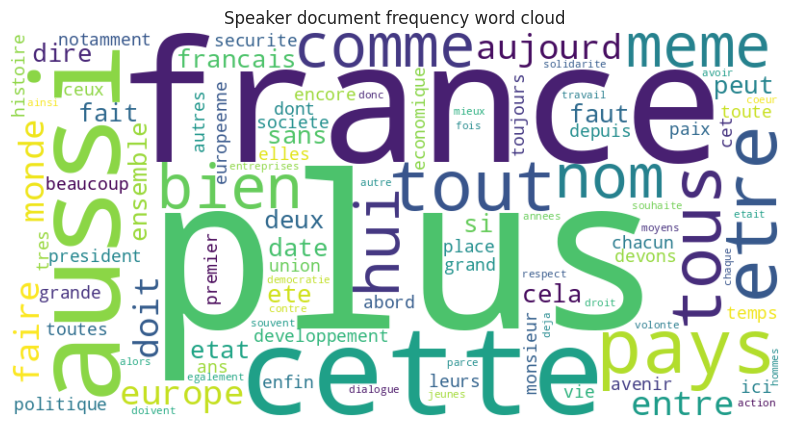

In [239]:
# 100 mots frequences documentaires
vect_tfidf = TfidfVectorizer(use_idf= True, smooth_idf=True, sublinear_tf=False, stop_words=french_stopwords)
X = vect_tfidf.fit_transform(all_texts_prec)
vocab = vect_tfidf.get_feature_names_out()
idf = vect_tfidf.idf_

# doc freq = inverse of idf, so getting the biggest df means getting the smallest idf 
idx_top_df = np.argsort(idf)[:100]
words_top_df = vocab[idx_top_df] 

wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab[idx_top_df], 1/idf[idx_top_df]))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Speaker document frequency word cloud")

plt.savefig("images/speaker_df_wordcloud_no_stopw.pdf", bbox_inches='tight')

print(f"100 mots avec la plus grande frequence doc:")
print(words_top_df)

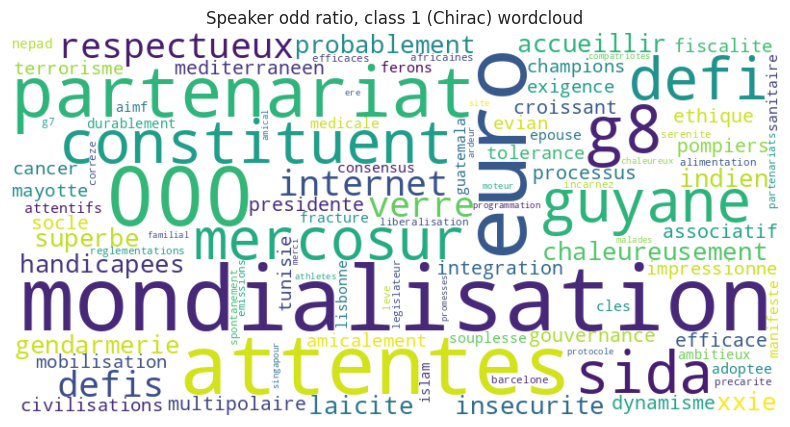

In [ ]:
# 100 mots odd ratio
vect = CountVectorizer(stop_words=french_stopwords, binary=True)
X = vect.fit_transform(all_texts_prec)
vocab = vect.get_feature_names_out()

idx0 =  np.where(np.array(alllabs) == -1)[0]
idx1 =  np.where(np.array(alllabs) == 1)[0]

X_class1 = X[idx1]
X_class0 = X[idx0]

a = np.array(X_class1.sum(axis=0)).flatten()
c = np.array(X_class0.sum(axis=0)).flatten()

b = X_class1.shape[0] - a
d = X_class0.shape[0] - c

odd_r = ((a + 1) / (b + 1)) / ((c + 1) / (d + 1))
log_or = np.log(odd_r)

# class 1 Chirac
idx_top = np.argsort(log_or)[-100:]
top_words = vocab[idx_top]

wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(top_words, np.abs(log_or[idx_top])))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Speaker odd ratio, class 1 (Chirac) wordcloud")

plt.savefig("images/speaker_OR_wordcloud_no_stopw_pos.pdf", bbox_inches='tight')

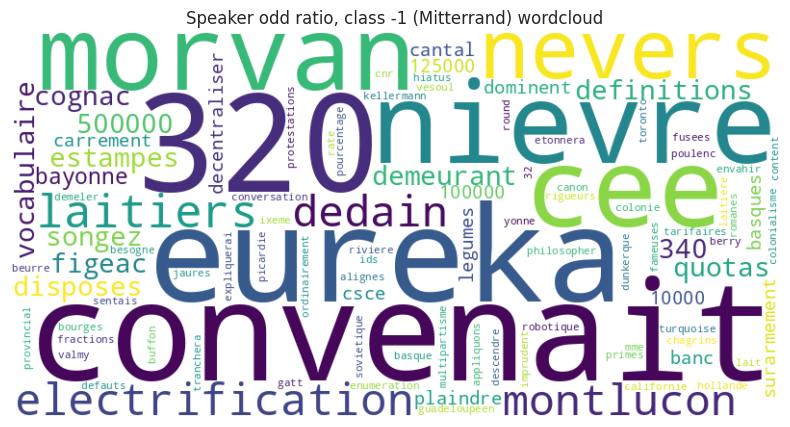

In [243]:
# class -1 Mitterrand
idx_bottom = np.argsort(log_or)[:100]
less_words = vocab[idx_bottom]

wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(less_words, -log_or[idx_bottom])))

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Speaker odd ratio, class -1 (Mitterrand) wordcloud")

plt.savefig("images/speaker_OR_wordcloud_no_stopw_neg.pdf", bbox_inches='tight')


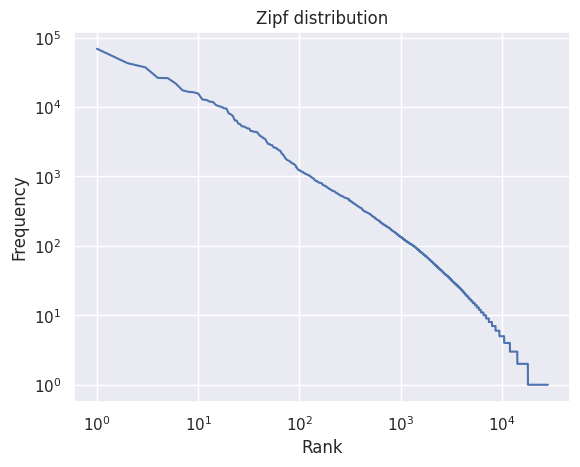

In [30]:
cv = CountVectorizer(stop_words=None)
X = cv.fit_transform(all_texts_prec)

# zipf law with stopwords
total_counts = np.asarray(X.sum(axis=0)).ravel()
sorted_counts = np.sort(total_counts)[::-1] # descending order
ranks = np.arange(1,len(sorted_counts)+1)
plt.plot(ranks,sorted_counts)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf distribution")
plt.xscale('log')
plt.yscale('log')
plt.savefig("images/speaker/speaker_zipf.pdf", bbox_inches='tight')

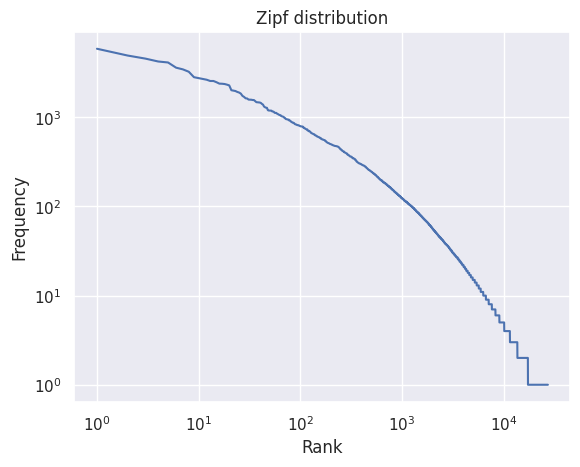

In [244]:
# zipf law
total_counts = np.asarray(X.sum(axis=0)).ravel()
sorted_counts = np.sort(total_counts)[::-1] # descending order
ranks = np.arange(1,len(sorted_counts)+1)
plt.plot(ranks,sorted_counts)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf distribution")
plt.xscale('log')
plt.yscale('log')
plt.savefig("images/speaker_zipf_no_stopw.pdf", bbox_inches='tight')


100 bigrammes les plus freq:
['aller plus' 'amerique latine' 'aucun doute' 'aujourd hui' 'autant plus'
 'beaucoup plus' 'bien entendu' 'celles ceux' 'celles tous'
 'certain nombre' 'cet esprit' 'cette annee' 'cette region' 'chacun entre'
 'chacune chacun' 'chaque annee' 'chaque jour' 'chefs etat' 'cher nom'
 'chers amis' 'cinq ans' 'collectivites locales'
 'communaute internationale' 'conseil securite' 'depuis date'
 'depuis longtemps' 'dernieres annees' 'deux pays'
 'developpement economique' 'dialogue social' 'doit etre' 'doivent etre'
 'droits homme' 'economique social' 'eh bien' 'entre deux' 'etat droit'
 'etat gouvernement' 'etats unis' 'etre plus' 'faire face' 'faire vivre'
 'faut aussi' 'femmes hommes' 'general gaulle' 'hommes femmes'
 'juste titre' 'lutte contre' 'meme si' 'meme temps' 'mesdames messieurs'
 'mettre oeuvre' 'mise oeuvre' 'mise place' 'monsieur maire'
 'monsieur president' 'nations unies' 'nom nom' 'non seulement'
 'outre mer' 'partenaires sociaux' 'pays plus' '

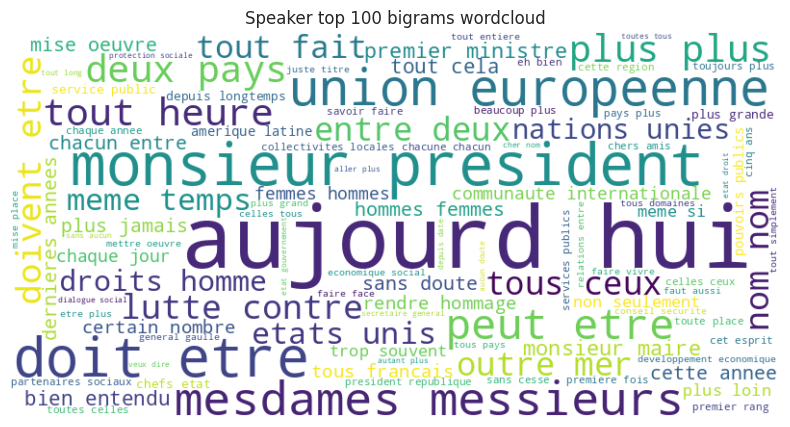

In [245]:
# bigrams most present
vectorizer_bi = CountVectorizer(ngram_range=(2, 2), max_features=100, stop_words=french_stopwords)
X_bi = vectorizer_bi.fit_transform(all_texts_prec)

vocab_bi = np.array(vectorizer_bi.get_feature_names_out())
frequencies = np.array(X_bi.sum(axis=0)).flatten()

# top 100 bigram most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab_bi, frequencies))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Speaker top 100 bigrams wordcloud")

plt.savefig("images/speaker_bigrams_wordcloud_no_stopw.pdf", bbox_inches='tight')

print("\n100 bigrammes les plus freq:")
print(vocab_bi[:100])


100 trigrams les plus freq:
['1er janvier date' 'aide publique developpement' 'aller plus loin'
 'ans plus tard' 'aujourd hui cette' 'aujourd hui comme'
 'aujourd hui encore' 'aujourd hui france' 'aujourd hui parmi'
 'aujourd hui plus' 'bonne heureuse annee' 'cas aujourd hui'
 'cela doit etre' 'cela va soi' 'cela veut dire' 'celles tous ceux'
 'cet apres midi' 'cette region monde' 'chacune chacun entre'
 'chaque jour plus' 'chefs etat gouvernement' 'conseil economique social'
 'cooperation entre deux' 'cours dernieres annees' 'crois peut dire'
 'declaration droits homme' 'departements outre mer'
 'depuis plusieurs annees' 'depuis quelques annees' 'depuis si longtemps'
 'disais tout heure' 'dit tout heure' 'doit etre fait'
 'droits homme citoyen' 'entre deux pays' 'etat collectivites locales'
 'etats unis amerique' 'etre aujourd hui' 'europe centrale orientale'
 'europe tout entiere' 'evoquais tout heure' 'evoquait tout heure'
 'faut aller plus' 'faut aujourd hui' 'fonds monetaire inte

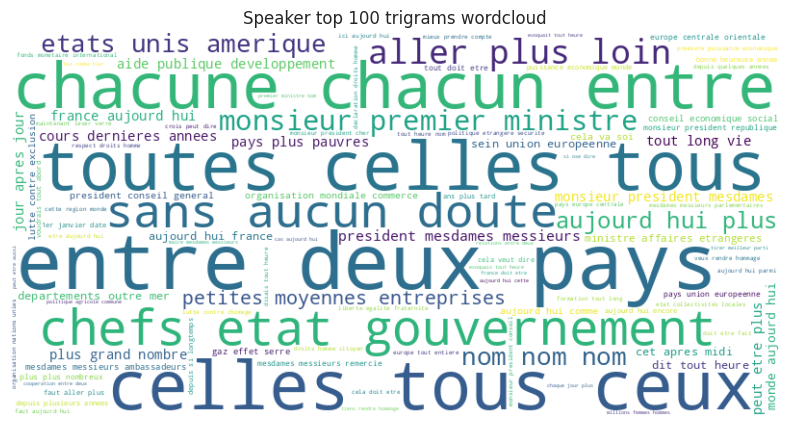

In [246]:
# tri-grams
vectorizer_tri = CountVectorizer(ngram_range=(3, 3), max_features=100, stop_words=french_stopwords)
X_tri = vectorizer_tri.fit_transform(all_texts_prec)

vocab_tri = np.array(vectorizer_tri.get_feature_names_out())
frequencies = np.array(X_tri.sum(axis=0)).flatten()

# top 100 bigram most frequent
wc = wordcloud.WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(dict(zip(vocab_tri, frequencies))) 

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title("Speaker top 100 trigrams wordcloud")

plt.savefig("images/speaker_trigrams_wordcloud_no_stopw.pdf", bbox_inches='tight')

print("\n100 trigrams les plus freq:")
print(vocab_tri[:100])